In [1]:
import matplotlib.pyplot as plt
import numpy as np
#%matplotlib widget
%matplotlib inline

# Guass elimination function

In [59]:
def show(A,fmt='%+7.2f'):
    """
    Function to more neatly print out the matrix.
    """
    print('--')
    for i, As in enumerate(A):
        cr=''
        for j, a in enumerate(As):
            cr=f'{cr} {fmt}'%a
        print(cr)

import numpy as np


def gauss(A):
    """
    Gauss elimination

    Arguments
    --------
    A: augmented matrix in  [n,n+1] dimension

    Returns
    -------
    Root in [n]-dimensional vector.
    """
    # swap and forward
    for icol in range(0,A.shape[0]-1):
        ## swap
        a=np.abs(A[icol:,icol])
        ind=np.argsort(a)
        ind=ind[::-1] # reverse order
        A[icol:,:]=A[icol:,:][ind,:]

        ## forward
        for irow in range(icol+1,A.shape[0]):
            A[irow,:]=A[irow,:]-A[irow,icol]/A[icol,icol]*A[icol,:]
    # now one could 'diagonalize'
    for icol in range(A.shape[0]-1,0,-1):
        for irow in range(0,icol):
            f=A[irow,icol]/A[icol,icol]
            A[irow,:]=A[irow,:]-f*A[icol,:]
    for icol in range(A.shape[0]):
        A[icol,:]=A[icol,:]/A[icol,icol]
    return A[:,-1]

# initial empty A.
A=np.zeros((3,4))
# filling up the matrix.
A[0,:]=2,3,3,9
A[1,:]=1,-1,1,1
A[2,:]=3,11,5,35
gauss(A)

array([ 21. ,   4.5, -15.5])

# Example 1 

$$
x^2+y^2=7
\newline
e^x+y=8
$$

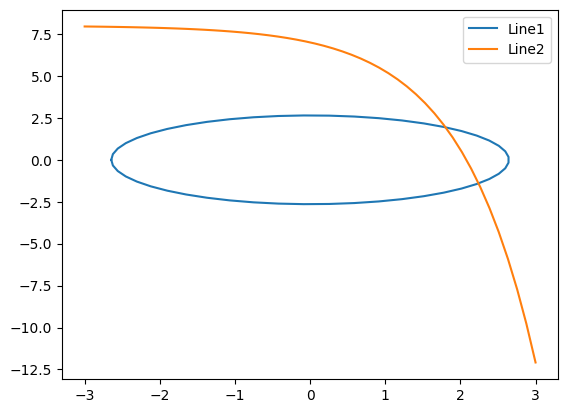

In [2]:
## 1st line
ths=np.linspace(-np.pi,np.pi)
r=np.sqrt(7)
x=np.cos(ths)*r
y=np.sin(ths)*r
plt.plot(x,y,label='Line1')
## 2nd line
x=np.linspace(-3,3)
y=8-np.exp(x)
plt.plot(x,y,label='Line2')
plt.legend()
#plt.gca().set_aspect('equal')

## Example 1 solution

In [57]:
## Canvas

## 1st line
ths=np.linspace(-np.pi,np.pi)
r=np.sqrt(7)
x=np.cos(ths)*r
y=np.sin(ths)*r

## 2nd line
x=np.linspace(-3,3)
y=8-np.exp(x)

## Function and Jacobian required for NR procedure
def func(x1,x2):
    f=np.zeros(2) #
    f[0]=x1**2+x2**2-7
    f[1]=np.exp(x1)+x2-8
    return f
def jacob(x1,x2):
    j=np.zeros((2,2)) # 2x2 jacob
    j[0,0]=2*x1
    j[0,1]=2*x2
    j[1,0]=np.exp(x1)
    j[1,1]=1
    return j

## NEWTON-RAPHSON begins here.
# hist arrays for recording changes.
## Initial guess
x=np.zeros(2) ## initial guess
x[::]=-1.0 ## initial guess

# Tolerance setting
tol=1e-9
err=tol*2
#
n=0
while err>tol and n<50:
    # jacobian and functions
    J=jacob(*x)
    F=func(*x)

    # Create augmented matrix A
    A=np.zeros((J.shape[0],J.shape[0]+1))
    A[:2,:2]=J[:,:]
    A[:,-1]=-F[::]

    # Obtain Delta x via guass elimination method
    dx=gauss(A)

    # Update x
    x=x+dx
    n+=1

    # estimate the error
    err=np.sqrt((F**2).sum())

print('solution:',x)

solution: [ 2.2413324  -1.40585528]


## Example 1 solution with Figures

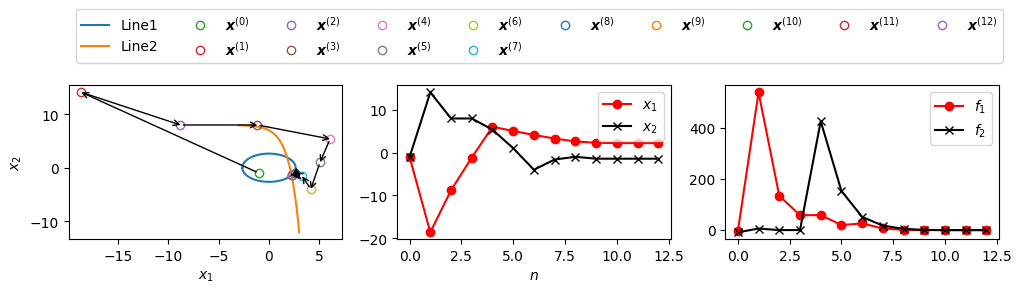

In [ ]:
## Canvas
fig=plt.figure(figsize=(12,2))
ax1=fig.add_subplot(131)
ax2=fig.add_subplot(132)
ax3=fig.add_subplot(133)

## 1st line
ths=np.linspace(-np.pi,np.pi)
r=np.sqrt(7)
x=np.cos(ths)*r
y=np.sin(ths)*r
ax1.plot(x,y,label='Line1')

## 2nd line
x=np.linspace(-3,3)
y=8-np.exp(x)
ax1.plot(x,y,label='Line2')

## Function and Jacobian required for NR procedure
def func(x1,x2):
    f=np.zeros(2) #
    f[0]=x1**2+x2**2-7
    f[1]=np.exp(x1)+x2-8
    return f
def jacob(x1,x2):
    j=np.zeros((2,2)) # 2x2 jacob
    j[0,0]=2*x1
    j[0,1]=2*x2
    j[1,0]=np.exp(x1)
    j[1,1]=1
    return j

## NEWTON-RAPHSON begins here.
# hist arrays for recording changes.
hist=[]
fhist=[]
## Initial guess
x=np.zeros(2) ## initial guess
x[::]=-1.0 ## initial guess

# Tolerance setting
tol=1e-9
err=tol*2
#
n=0
while err>tol and n<50:
    # plotting the trajectory of vector x.
    ax1.plot(*x,'o',mfc='None',label=r'$\boldsymbol{x}^{(%i)}$'%n)

    # jacobian and functions
    J=jacob(*x)
    F=func(*x)

    # history
    hist.append(x)
    fhist.append(F)

    # Create augmented matrix A
    A=np.zeros((J.shape[0],J.shape[0]+1))
    A[:2,:2]=J[:,:]
    A[:,-1]=-F[::]

    # Obtain Delta x via guass elimination method
    dx=gauss(A)

    #
    ax1.annotate( "", xy=x, xytext=x+dx,
              arrowprops=dict( arrowstyle="<-",shrinkA=0 ) )
    mid=np.array(x)+np.array(dx)/2.
    x=x+dx
    n+=1
    err=np.sqrt((F**2).sum())

hist=np.array(hist)
fhist=np.array(fhist)

ax1.legend(loc='lower left',bbox_to_anchor=(0,1.1),ncols=10)
ax1.set_xlabel(r'$x_1$')
ax1.set_ylabel(r'$x_2$')
ax2.plot(hist[:,0],'-ro',label=r'$x_1$')
ax2.plot(hist[:,1],'-kx',label=r'$x_2$')
ax3.plot(fhist[:,0],'-ro',label=r'$f_1$')
ax3.plot(fhist[:,1],'-kx',label=r'$f_2$')
ax2.set_xlabel(r'$n$')
for i, ax in enumerate(fig.axes[1:]):
    ax.legend()
## guass elimination


# Example 2

$$
xy=10
\newline
x^2-y=3
$$

NR 적용위해 함수 형태로 표현하면
$$
f_1(x,y)=xy-10
\newline
f_2(x,y)=x^2-y-3
$$

line1
$$
y=10/x
$$

Line 2
$$
y=x^2-3
$$

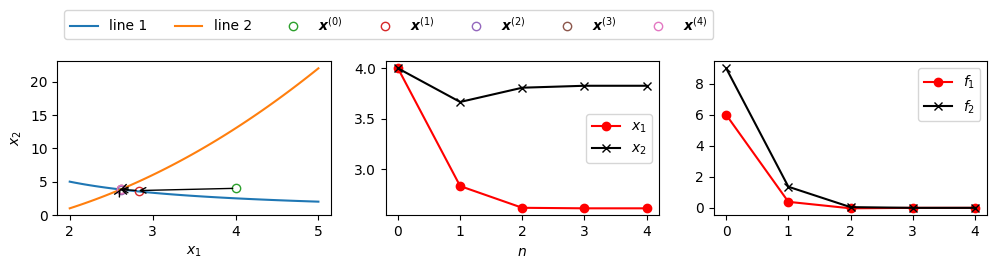

In [129]:
import numpy as np
import matplotlib.pyplot as plt

def f1(x,y):  return x*y-10
def f2(x,y):  return x**2-y-3
def func(x,y): return np.array([f1(x,y),f2(x,y)])

def jacob(x,y):
    j=np.zeros((2,2))
    j[0,0]=y
    j[0,1]=x
    j[1,0]=2*x
    j[1,1]=-1
    return j

xs=np.linspace(2,5)

## Canvas
fig=plt.figure(figsize=(12,2))
ax1=fig.add_subplot(131)
ax2=fig.add_subplot(132)
ax3=fig.add_subplot(133)

## line 1
ax1.plot(xs,10/xs,label='line 1')
## line 2
ax1.plot(xs,xs**2-3,label='line 2')
ax1.legend()


## NEWTON-RAPHSON begins here.
# hist arrays for recording changes.
hist=[]
fhist=[]
## Initial guess
x=np.zeros(2) ## initial guess
x[::]=4.0 ## initial guess

# Tolerance setting
tol=1e-9
err=tol*2
#
n=0
while err>tol and n<50:
    # plotting the trajectory of vector x.
    ax1.plot(*x,'o',mfc='None',label=r'$\boldsymbol{x}^{(%i)}$'%n)

    # jacobian and functions
    J=jacob(*x)
    F=func(*x)

    # history
    hist.append(x)
    fhist.append(F)

    # Create augmented matrix A
    A=np.zeros((J.shape[0],J.shape[0]+1))
    A[:2,:2]=J[:,:]
    A[:,-1]=-F[::]

    # Obtain Delta x via guass elimination method
    dx=gauss(A)

    #
    ax1.annotate( "", xy=x, xytext=x+dx,
              arrowprops=dict( arrowstyle="<-",shrinkA=0 ) )
    mid=np.array(x)+np.array(dx)/2.
    x=x+dx
    n+=1
    err=np.sqrt((F**2).sum())

hist=np.array(hist)
fhist=np.array(fhist)

ax1.legend(loc='lower left',bbox_to_anchor=(0,1.1),ncols=10)
ax1.set_xlabel(r'$x_1$')
ax1.set_ylabel(r'$x_2$')
ax2.plot(hist[:,0],'-ro',label=r'$x_1$')
ax2.plot(hist[:,1],'-kx',label=r'$x_2$')
ax3.plot(fhist[:,0],'-ro',label=r'$f_1$')
ax3.plot(fhist[:,1],'-kx',label=r'$f_2$')
ax2.set_xlabel(r'$n$')
for i, ax in enumerate(fig.axes[1:]):
    ax.legend()
## guass elimination